In [2]:
# -----------------------------------------------------------------------------
# PROJETO: Detecção de Tráfego Malicioso em Redes Corporativas
# CURSO: Inteligência Artificial - 7º CC - Universidade Presbiteriana Mackenzie
#
# INTEGRANTES DO GRUPO:
# - Victor Hong (RA: 10425852)
# - Mauricio Vicentini (RA: 10426074)
# - Lucas Crepalde (RA: 10425647)
# - Rafael Riki (RA: 10418331)
# - Henrique Higa (RA: 10402805)
#
# SÍNTESE DO ARQUIVO:
# Este notebook contém a Análise Exploratória de Dados (EDA) e a etapa de 
# preparação dos dados do dataset público UNSW-NB15. O objetivo é carregar, 
# inspecionar as correlações do tráfego de rede, tratar valores nulos, 
# aplicar enconding em protocolos/serviços e normalizar as features para o 
# treinamento dos modelos de Machine Learning supervisionado.
#
# HISTÓRICO DE ALTERAÇÕES:
# - 24/09/2026 | Victor Hong | Criação do arquivo, inserção do cabeçalho obrigatório e importações base.
# - 24/09/2026 | Equipe      | Implementação das rotinas de EDA e visualização gráfica de tráfego.
# - 24/09/2026 | Equipe      | Codificação de variáveis categóricas, normalização e separação de treino/teste.
# -----------------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Configurações visuais para os gráficos
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Carregamento do Dataset UNSW-NB15
# Nota: Ajuste o caminho do arquivo para refletir o nome exato do seu arquivo .parquet
file_path = 'UNSW_NB15_training-set.parquet' 

try:
    # Lendo o arquivo parquet utilizando o motor pyarrow
    df = pd.read_parquet(file_path, engine='pyarrow')
    print("Dataset carregado com sucesso!")
    print(f"Dimensões originais: {df.shape[0]} linhas e {df.shape[1]} colunas.")
except FileNotFoundError:
    print(f"Erro: Arquivo não encontrado no caminho {file_path}. Verifique o diretório e o nome do arquivo.")
except ImportError:
    print("Erro: A biblioteca 'pyarrow' não está instalada. Execute 'pip install pyarrow' no terminal.")

# Visualizando as primeiras linhas
display(df.head())

# Verificando os tipos de dados e a presença de valores nulos
print("\nInformações das Variáveis:")
df.info()

Dataset carregado com sucesso!
Dimensões originais: 175341 linhas e 36 colunas.


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0



Informações das Variáveis:
<class 'pandas.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   dur                175341 non-null  float32 
 1   proto              175341 non-null  category
 2   service            175341 non-null  category
 3   state              175341 non-null  category
 4   spkts              175341 non-null  int16   
 5   dpkts              175341 non-null  int16   
 6   sbytes             175341 non-null  int32   
 7   dbytes             175341 non-null  int32   
 8   rate               175341 non-null  float32 
 9   sload              175341 non-null  float32 
 10  dload              175341 non-null  float32 
 11  sloss              175341 non-null  int16   
 12  dloss              175341 non-null  int16   
 13  sinpkt             175341 non-null  float32 
 14  dinpkt             175341 non-null  float32 
 15  sjit             

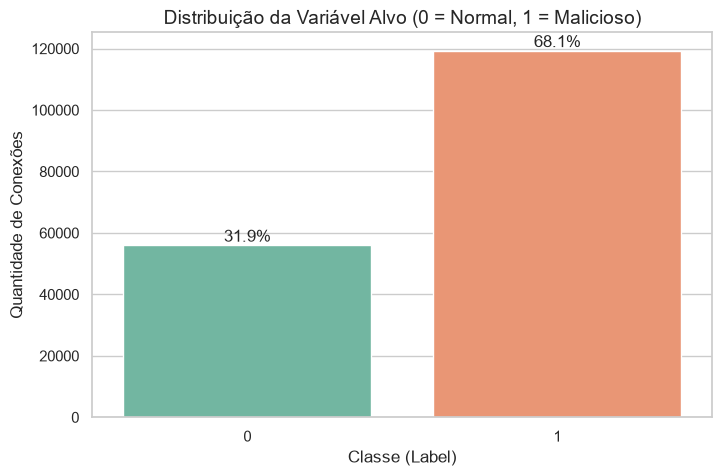

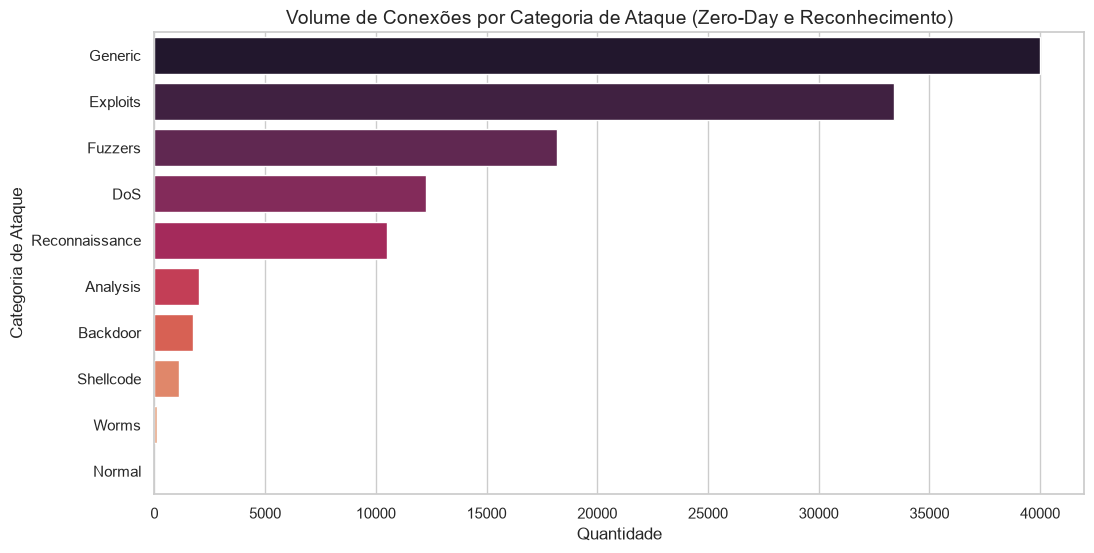

In [4]:
# 1. Distribuição da Variável Alvo (Tráfego Normal vs. Anômalo/Malicioso)
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='label', data=df, palette='Set2')
plt.title('Distribuição da Variável Alvo (0 = Normal, 1 = Malicioso)', fontsize=14)
plt.xlabel('Classe (Label)')
plt.ylabel('Quantidade de Conexões')

# Adicionando os percentuais acima das barras
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12)
plt.show()

# 2. Distribuição das Categorias de Ataque (Caso o tráfego seja malicioso)
plt.figure(figsize=(12, 6))
sns.countplot(y='attack_cat', data=df[df['label'] == 1], 
              order=df[df['label'] == 1]['attack_cat'].value_counts().index, 
              palette='rocket')
plt.title('Volume de Conexões por Categoria de Ataque (Zero-Day e Reconhecimento)', fontsize=14)
plt.xlabel('Quantidade')
plt.ylabel('Categoria de Ataque')
plt.show()

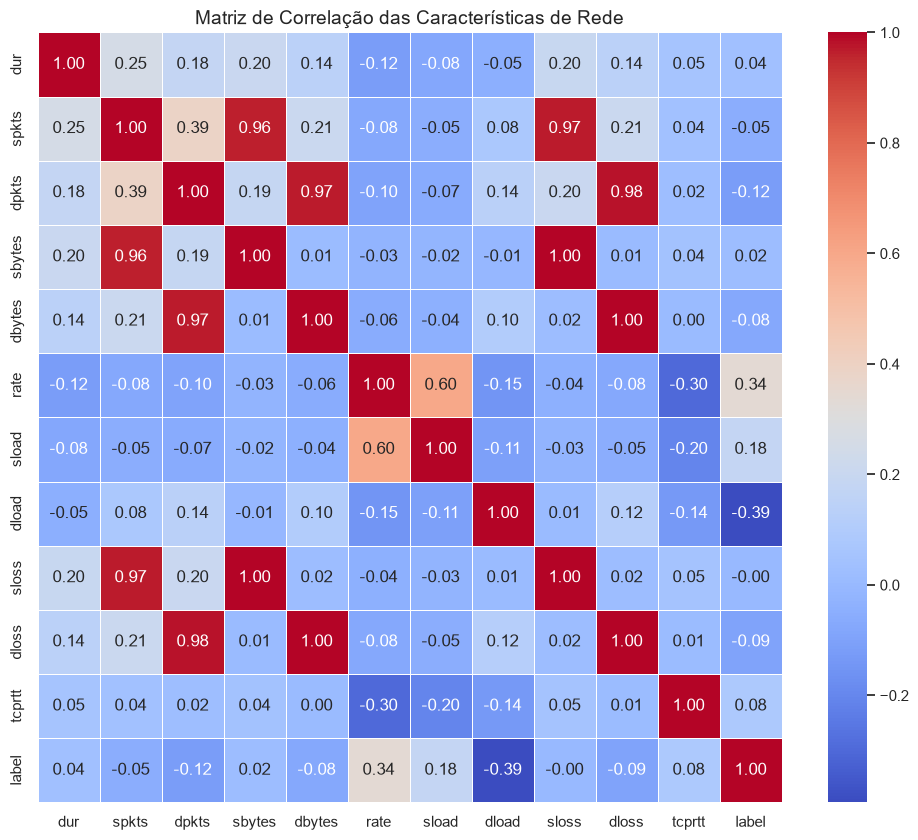

In [7]:
# Características focadas em volume, taxa, perda de pacotes e latência
cols_de_interesse = [
    'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 
    'rate', 'sload', 'dload', 'sloss', 'dloss', 
    'tcprtt', 'label'
]

plt.figure(figsize=(12, 10))
correlation_matrix = df[cols_de_interesse].corr()

# Plotando o Heatmap para identificar redundâncias
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação das Características de Rede', fontsize=14)
plt.show()

In [8]:
# 1. Remoção de identificadores inúteis e features redundantes para evitar viés no modelo
colunas_para_remover = ['id'] 
if 'id' in df.columns:
    df.drop(columns=colunas_para_remover, inplace=True)

# 2. Tratamento da coluna 'attack_cat' (remoção de NaNs para tráfego normal)
if 'attack_cat' in df.columns:
    df['attack_cat'].fillna('Normal', inplace=True)
    # Guardamos a categoria exata separada para análises futuras, mas o ML usará apenas 'label'
    y_multiclass = df['attack_cat']
    df.drop(columns=['attack_cat'], inplace=True)

# Separando Variáveis Preditoras (X) e Alvo (y)
X = df.drop(columns=['label'])
y = df['label']

print(f"Limpeza concluída. Features restantes: {X.shape[1]}")

Limpeza concluída. Features restantes: 34


In [10]:
# Identificando colunas categóricas considerando o formato parquet ('category' ou 'object')
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

print(f"Variáveis Categóricas identificadas: {cat_cols}")

# Aplicando Label Encoding nas variáveis categóricas de rede
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    # Converte para string antes do encoding para evitar erros com valores nulos/tipos mistos
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Dividindo os dados (70% para treinamento e 30% para testes de avaliação do modelo)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Normalizando as variáveis numéricas com StandardScaler 
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f"\nConjunto de Treino: {X_train.shape[0]} amostras.")
print(f"Conjunto de Teste: {X_test.shape[0]} amostras.")
print("\nPipeline de Preparação de Dados Concluído com Sucesso! Os dados estão prontos para a modelagem.")

Variáveis Categóricas identificadas: ['proto', 'service', 'state']

Conjunto de Treino: 122738 amostras.
Conjunto de Teste: 52603 amostras.

Pipeline de Preparação de Dados Concluído com Sucesso! Os dados estão prontos para a modelagem.
